# Lab 2: Memory-based CF

## Section 1: Reload / Revisit Movielens 10M dataset and TopPop recommender

#### Dataset: https://grouplens.org/datasets/movielens/10m/

In [1]:
from urllib.request import urlretrieve
import zipfile, os

In [2]:
# If file exists, skip the download
data_file_path = "movielens/Movielens10M/"
data_file_name = data_file_path + "movielens_10m.zip"

# If directory does not exist, create
if not os.path.exists(data_file_path):
    os.makedirs(data_file_path)

if not os.path.exists(data_file_name):
    urlretrieve("http://files.grouplens.org/datasets/movielens/ml-10m.zip", data_file_name)

In [3]:
# unzip and read the ratings.dat file
dataFile = zipfile.ZipFile(data_file_path + "movielens_10m.zip")

mv_path = dataFile.extract("ml-10M100K/ratings.dat", path = data_file_path)

#### Let's take a look at the data

In [4]:
import pandas as pd

In [5]:
mv_df = pd.read_csv(filepath_or_buffer=mv_path, sep="::", header=None, dtype={0:int, 1:int, 2:float, 3:int}, engine='python')

mv_df.columns = ["UserID", "ItemID", "Interaction", "Timestamp"]

In [6]:
mv_df.head(n=10)

,UserID,ItemID,Interaction,Timestamp
0,1,122,5.0,838985046
1,1,185,5.0,838983525
2,1,231,5.0,838983392
3,1,292,5.0,838983421
4,1,316,5.0,838983392
5,1,329,5.0,838983392
6,1,355,5.0,838984474
7,1,356,5.0,838983653
8,1,362,5.0,838984885
9,1,364,5.0,838983707


In [7]:
print("The number of interactions is {}".format(len(mv_df)))

The number of interactions is 10000054


#### We will now create a sparse matrix

<u>Note</u> : we read UserID and ItemID as int, but this is not always the case if the IDs are alphanumeric

#### Let's extract the list of unique user id and item id, and show some statistics to understand our data

In [8]:
userID_unique = mv_df["UserID"].unique()
itemID_unique = mv_df["ItemID"].unique()

In [9]:
n_users = len(userID_unique)
n_items = len(itemID_unique)
n_interactions = len(mv_df)

print("Number of users: {}\t, Number of items: {}".format(n_users, n_items))
print("Max UserID: {}\t, Max ItemID: {}".format(max(userID_unique), max(itemID_unique)))

Number of users: 69878	, Number of items: 10677
Max UserID: 71567	, Max ItemID: 65133


#### We observe that the max ID of users and items is higher than the number of unique users and items. Thus, we have some empty profiles

#### We should remove those empty indices, by creating a new mapping

In [10]:
mapped_id, original_id = pd.factorize(mv_df["UserID"].unique())
user_original_ID_to_index = pd.Series(mapped_id, index=original_id)

mapped_id, original_id = pd.factorize(mv_df["ItemID"].unique())
item_original_ID_to_index = pd.Series(mapped_id, index=original_id)

In [11]:
original_item_ID = 292
print("New index for item {} is {}".format(original_item_ID, item_original_ID_to_index[original_item_ID]))

New index for item 292 is 3


#### Replacing the IDs in the dataframe and we are ready to use the data

In [12]:
mv_df["UserID"] = mv_df["UserID"].map(user_original_ID_to_index)
mv_df["ItemID"] = mv_df["ItemID"].map(item_original_ID_to_index)

In [13]:
mv_df.head(n=10)

,UserID,ItemID,Interaction,Timestamp
0,0,0,5.0,838985046
1,0,1,5.0,838983525
2,0,2,5.0,838983392
3,0,3,5.0,838983421
4,0,4,5.0,838983392
5,0,5,5.0,838983392
6,0,6,5.0,838984474
7,0,7,5.0,838983653
8,0,8,5.0,838984885
9,0,9,5.0,838983707


In [14]:
userID_unique = mv_df["UserID"].unique()
itemID_unique = mv_df["ItemID"].unique()

n_users = len(userID_unique)
n_items = len(itemID_unique)
n_interactions = len(mv_df)

print("Number of users: {}\t, Number of items: {}".format(n_users, n_items))
print("Max UserID: {}\t, Max ItemID: {}\n".format(max(userID_unique), max(itemID_unique)))

print("Average interactions per user: {:.2f}".format(n_interactions/n_users))
print("Average interactions per item: {:.2f}\n".format(n_interactions/n_items))

print("Sparsity {:.2f} %".format((1-float(n_interactions)/(n_users*n_items))*100))

Number of users: 69878	, Number of items: 10677
Max UserID: 69877	, Max ItemID: 10676

Average interactions per user: 143.11
Average interactions per item: 936.60

Sparsity 98.66 %


In [15]:
import scipy.sparse as sps
import numpy as np

mv_all = sps.coo_matrix((mv_df['Interaction'].values, (mv_df['UserID'].values, mv_df['ItemID'].values)))

mv_all

<69878x10677 sparse matrix of type '<class 'numpy.float64'>'
	with 10000054 stored elements in COOrdinate format>

In [16]:
item_popularity = np.ediff1d(mv_all.tocsc().indptr)
item_popularity

array([ 2412, 14975, 17851, ...,     1,     1,     1], dtype=int32)

In [17]:
ten_percent = int(n_items/10)

print("Average per-item interactions over the whole dataset: {:.2f}".
      format(item_popularity.mean()))

print("Average per-item interactions for the top 10% popular items: {:.2f}".
      format(item_popularity[-ten_percent:].mean()))

print("Average per-item interactions for the least 10% popular items: {:.2f}".
      format(item_popularity[:ten_percent].mean()))

print("Average per-item interactions for the median 10% popular items: {:.2f}".
      format(item_popularity[int(n_items*0.45):int(n_items*0.55)].mean()))

Average per-item interactions over the whole dataset: 936.60
Average per-item interactions for the top 10% popular items: 9.34
Average per-item interactions for the least 10% popular items: 4980.56
Average per-item interactions for the median 10% popular items: 231.25


In [18]:
print("Number of items with zero interactions {}".format(np.sum(item_popularity==0)))

Number of items with zero interactions 0


#### Evaluation:

#### In order to evaluate our recommender, we have to:
* Split the data into mv_train and mv_test (i.e., train and test set)
* Define evaluation metrics
* Define a functon to compute the evaluation for each user

<u>Note</u>: The splitting of the data is very important to ensure your algorithm is evaluated appropriately

In [19]:
train_test_split = 0.80

n_interactions = mv_all.nnz


train_mask = np.random.choice([True, False], n_interactions, p=[train_test_split, 1-train_test_split])
train_mask

array([False,  True,  True, ...,  True,  True,  True])

In [20]:
mv_train = sps.csr_matrix((mv_all.data[train_mask], (mv_all.row[train_mask], mv_all.col[train_mask])))

mv_train

<69878x10677 sparse matrix of type '<class 'numpy.float64'>'
	with 7999785 stored elements in Compressed Sparse Row format>

In [21]:
test_mask = np.logical_not(train_mask)

mv_test = sps.csr_matrix((mv_all.data[test_mask], (mv_all.row[test_mask], mv_all.col[test_mask])))

mv_test

<69878x10674 sparse matrix of type '<class 'numpy.float64'>'
	with 2000269 stored elements in Compressed Sparse Row format>

#### Evaluation metric

#### We call items in the test set 'relevant'

In [22]:
user_id = 124
relevant_items = mv_test[user_id].indices
relevant_items

array([   5,    8,   11,   18,   20,   29,   37,   47,   74,   79,   88,
         93,  139,  150,  170,  181,  220,  340,  415,  418, 1008, 1280,
       1310, 1466, 2310, 2492], dtype=int32)

#### Assume that we have a recommendation list such as:

In [23]:
recommended_items = np.array([241, 1622, 15, 857, 5823])
recommended_items

array([ 241, 1622,   15,  857, 5823])

In [24]:
is_relevant = np.in1d(recommended_items, relevant_items, assume_unique=True)
is_relevant

array([False, False, False, False, False])

#### Precision: how many of the recommended items are relevant

In [25]:
def precision(recommended_items, relevant_items):

    is_relevant = np.in1d(recommended_items,relevant_items)

    precision_score = np.sum(is_relevant) / len(is_relevant)

    return precision_score

#### Recall: how many of the relevant items I was able to recommend

In [26]:
def recall(recommended_items, relevant_items):

    is_relevant = np.in1d(recommended_items,relevant_items)

    recall_score = np.sum(is_relevant) / relevant_items.shape[0]

    return recall_score

#### Average Precision

In [27]:
def AP(recommended_items, relevant_items):

    is_relevant = np.in1d(recommended_items, relevant_items, assume_unique=True)

    # Cumulative sum: precision at 1, at 2, at 3 ...
    p_at_k = is_relevant * np.cumsum(is_relevant, dtype=np.float32) / (1 + np.arange(is_relevant.shape[0]))

    ap_score = np.sum(p_at_k) / np.min([relevant_items.shape[0], is_relevant.shape[0]])

    return ap_score

#### Put evaluate algorithm

In [55]:
# We pass as paramether the recommender class

def evaluate_algorithm(mv_test, recommender_object, at=5):

    cumulative_precision = 0.0
    cumulative_recall = 0.0
    cumulative_AP = 0.0

    num_eval = 0


    for user_id in range(mv_test.shape[0]):

        relevant_items = mv_test.indices[mv_test.indptr[user_id]:mv_test.indptr[user_id+1]]

        if len(relevant_items)>0:

            recommended_items = recommender_object.recommend(user_id, at=at)
            num_eval += 1

            cumulative_precision += precision(recommended_items, relevant_items)
            cumulative_recall += recall(recommended_items, relevant_items)
            cumulative_AP += AP(recommended_items, relevant_items)

    cumulative_precision /= num_eval
    cumulative_recall /= num_eval
    MAP = cumulative_AP / num_eval

    print("Recommender results are: Precision = {:.4f}, Recall = {:.4f}, MAP = {:.4f}".format(
        cumulative_precision, cumulative_recall, MAP))


#### We already built a random recommender in the previous lab

#### Now, let's build a Top Popular (TopPop) recommender

### Top Popular (TopPop) recommender

#### We recommend to all users the most popular items, that is those with the highest number of interactions
#### In this case our model is the item popularity

In [56]:
class TopPopRecommender(object):

  def fit(self, mv_train):

      item_popularity = np.ediff1d(mv_train.tocsc().indptr)

      # We are not interested in sorting the popularity value,
      # but to order the items according to it
      self.popular_items = np.argsort(item_popularity)
      self.popular_items = np.flip(self.popular_items, axis=0)

  def recommend(self, user_id, at=5):

      recommended_items = self.popular_items[0:at]

      return recommended_items

#### Now train and test our model

In [57]:
topPopRecommender = TopPopRecommender()
topPopRecommender.fit(mv_train)

In [58]:
for user_id in range(10):
    print(topPopRecommender.recommend(user_id, at=5))

[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139   14 1293]


In [59]:
evaluate_algorithm(mv_test, topPopRecommender, at=5)

Recommender results are: Precision = 0.0953, Recall = 0.0308, MAP = 0.0526


### That's better! But we can still improve

##### <u>Hint</u>: remove items already seen by the user. We can either remove them from the recommended item list or we can set them to a score so low that it will cause them to end at the very bottom of all the available items

In [60]:
class TopPopRecommender(object):

    def fit(self, mv_train):

        self.mv_train = mv_train

        item_popularity = np.ediff1d(mv_all.tocsc().indptr)

        # We are not interested in sorting the popularity value,
        # but to order the items according to it
        self.popular_items = np.argsort(item_popularity)
        self.popular_items = np.flip(self.popular_items, axis=0)

    def recommend(self, user_id, at=5, remove_seen=True):

        if remove_seen:
            seen_items = self.mv_train.indices[self.mv_train.indptr[user_id]:self.mv_train.indptr[user_id+1]]

            unseen_items_mask = np.in1d(self.popular_items, seen_items, assume_unique=True, invert=True)

            unseen_items = self.popular_items[unseen_items_mask]

            recommended_items = unseen_items[0:at]

        else:
            recommended_items = self.popular_items[0:at]


        return recommended_items

In [61]:
topPopRecommender_removeSeen = TopPopRecommender()
topPopRecommender_removeSeen.fit(mv_train)

for user_id in range(10):
    print(topPopRecommender_removeSeen.recommend(user_id, at=5))

[1008  139 1293   22  175]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7  139 1293   22]
[1008    7  139   14 1293]
[1008    7  139   14 1293]
[1008    7   14 1293   22]
[1008    7 1293   22   19]
[1008    7  139   14 1293]
[   7   14 1293   22   19]


In [62]:
evaluate_algorithm(mv_test, topPopRecommender_removeSeen)

Recommender results are: Precision = 0.1984, Recall = 0.0532, MAP = 0.1471


#### Simple but effective. Always remove seen items if your purpose is to recommend "new" ones

## Section 2: Global Effect recommender

#### We recommend to all users the highest rated items

#### First we compute the average of all ratings, or global average

In [63]:
globalAverage = np.mean(mv_train.data)

print("The global average is {:.2f}".format(globalAverage))

The global average is 3.51


#### We substract this bias to all ratings

In [64]:
mv_train_unbiased = mv_train.copy()

mv_train_unbiased.data -= globalAverage

print(mv_train_unbiased.data[0:10])

[1.48763873 1.48763873 1.48763873 1.48763873 1.48763873 1.48763873
 1.48763873 1.48763873 1.48763873 1.48763873]


#### Then we compute the average rating for each item, or item bias

In [72]:
item_mean_rating = mv_train_unbiased.mean(axis=0)
item_mean_rating

matrix([[-1.82077359e-02, -6.47384023e-02, -1.18155492e-01, ...,
         -2.16428814e-05,  6.97842998e-06,  6.97842998e-06]])

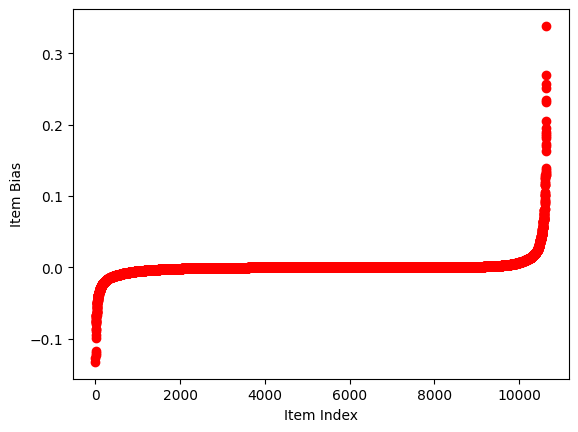

In [73]:
import matplotlib.pyplot as pyplot

item_mean_rating = np.array(item_mean_rating).squeeze()
item_mean_rating = np.sort(item_mean_rating[item_mean_rating!=0])

pyplot.plot(item_mean_rating, 'ro')
pyplot.ylabel('Item Bias')
pyplot.xlabel('Item Index')
pyplot.show()

#### And the average rating for each user, or user bias

In [74]:
user_mean_rating = mv_train_unbiased.mean(axis=1)
user_mean_rating

matrix([[ 0.0022293 ],
        [-0.00025151],
        [ 0.00122967],
        ...,
        [ 0.00384506],
        [ 0.00098394],
        [-0.00173218]])

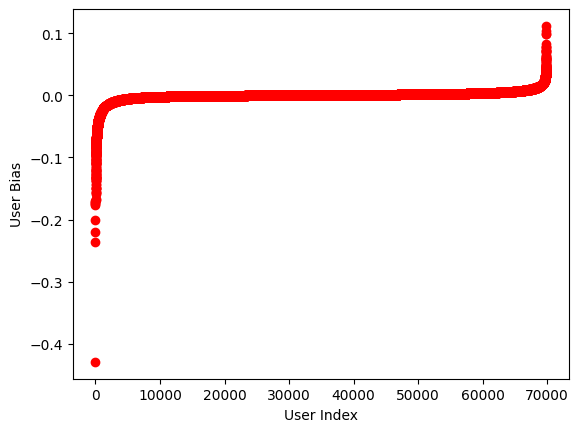

In [75]:
user_mean_rating = np.array(user_mean_rating).squeeze()
user_mean_rating = np.sort(user_mean_rating[user_mean_rating!=0.0])

pyplot.plot(user_mean_rating, 'ro')
pyplot.ylabel('User Bias')
pyplot.xlabel('User Index')
pyplot.show()

#### Now we can sort the items by their item bias and use the same recommendation principle as in TopPop recommender

In [76]:
class GlobalEffectsRecommender(object):

    def fit(self, mv_train):

        self.mv_train = mv_train

        globalAverage = np.mean(mv_train.data)

        mv_train_unbiased = mv_train.copy()
        mv_train_unbiased.data -= globalAverage

        item_mean_rating = mv_train_unbiased.mean(axis=0)
        item_mean_rating = np.array(item_mean_rating).squeeze()

        self.bestRatedItems = np.argsort(item_mean_rating)
        self.bestRatedItems = np.flip(self.bestRatedItems, axis=0)


    def recommend(self, user_id, at=5, remove_seen=True):

        if remove_seen:

            unseen_items_mask = np.in1d(self.bestRatedItems, mv_train[user_id].indices, assume_unique=True, invert = True)

            unseen_items = self.bestRatedItems[unseen_items_mask]

            recommended_items = unseen_items[0:at]

        else:
            recommended_items = self.bestRatedItems[0:at]


        return recommended_items

In [77]:
globalEffectsRecommender = GlobalEffectsRecommender()
globalEffectsRecommender.fit(mv_train)

evaluate_algorithm(mv_test, globalEffectsRecommender)

Recommender results are: Precision = 0.1695, Recall = 0.0390, MAP = 0.1228


#### Now let's try to combine user bias and item bias

In [78]:
class GlobalEffectsRecommender(object):

    def fit(self, mv_train):

        self.mv_train = mv_train

        globalAverage = np.mean(mv_train.data)

        mv_train_unbiased = mv_train.copy()
        mv_train_unbiased.data -= globalAverage

        # User Bias
        user_mean_rating = mv_train_unbiased.mean(axis=1)
        user_mean_rating = np.array(user_mean_rating).squeeze()

        # In order to apply the user bias we have to change the rating value
        # in the mv_train_unbiased inner data structures
        # If we were to write:
        # mv_train_unbiased[user_id].data -= user_mean_rating[user_id]
        # we would change the value of a new matrix with no effect on the original data structure
        for user_id in range(len(user_mean_rating)):
            start_position = mv_train_unbiased.indptr[user_id]
            end_position = mv_train_unbiased.indptr[user_id+1]

            mv_train_unbiased.data[start_position:end_position] -= user_mean_rating[user_id]

        # Item Bias
        item_mean_rating = mv_train_unbiased.mean(axis=0)
        item_mean_rating = np.array(item_mean_rating).squeeze()

        self.bestRatedItems = np.argsort(item_mean_rating)
        self.bestRatedItems = np.flip(self.bestRatedItems, axis=0)



    def recommend(self, user_id, at=5, remove_seen=True):

        if remove_seen:

            unseen_items_mask = np.in1d(self.bestRatedItems, mv_train[user_id].indices, assume_unique=True, invert = True)

            unseen_items = self.bestRatedItems[unseen_items_mask]

            recommended_items = unseen_items[0:at]

        else:
            recommended_items = self.bestRatedItems[0:at]


        return recommended_items


In [79]:
globalEffectsRecommender = GlobalEffectsRecommender()
globalEffectsRecommender.fit(mv_train)

evaluate_algorithm(mv_test, globalEffectsRecommender)

Recommender results are: Precision = 0.1695, Recall = 0.0390, MAP = 0.1228


#### The results are indeed identical! User bias is essential in case of rating prediction but not really relevant in case of top-K recommendations.

### Question:

#### Why is GlobalEffect performing worse than TopPop even if we are taking into account more information about the interaction?

### Answer:

#### The test data contains a lot of low rating interactions... We are testing against those as well, but GlobalEffects is penalizing interactions with low rating

#### In reality we want to recommend items rated in a positive way, so let's build a new Test set with positive interactions only

In [80]:
mv_test_positiveOnly = mv_test.copy()

mv_test_positiveOnly.data[mv_test.data<=2] = 0
mv_test_positiveOnly.eliminate_zeros()
mv_test_positiveOnly

<69878x10674 sparse matrix of type '<class 'numpy.float64'>'
	with 1723171 stored elements in Compressed Sparse Row format>

In [81]:
print("Deleted {} negative interactions".format(mv_test.nnz - mv_test_positiveOnly.nnz))

Deleted 277098 negative interactions


#### Run the evaluation again for both

In [82]:
evaluate_algorithm(mv_test_positiveOnly, topPopRecommender_removeSeen)

Recommender results are: Precision = 0.1886, Recall = 0.0567, MAP = 0.1389


In [83]:
evaluate_algorithm(mv_test_positiveOnly, globalEffectsRecommender)

Recommender results are: Precision = 0.1637, Recall = 0.0422, MAP = 0.1187


### Sometimes ratings are not really more informative than interactions, depends on their quality

## Section 3: Item-based Collaborative Filtering (with Surprise)

#### Dataset: https://grouplens.org/datasets/movielens/100k/

In [92]:
!pip install surprise

In [93]:
import numpy as np
import pandas as pd
import heapq
from surprise import Dataset, Reader
from surprise import KNNBasic
from surprise.similarities import cosine, msd, pearson
from surprise import accuracy
from surprise.model_selection import train_test_split

In [99]:
# If file exists, skip the download
data_100k_file_path = "movielens/Movielens100K/"
data_100k_file_name = data_100k_file_path + "ml-100k.zip"

# If directory does not exist, create
if not os.path.exists(data_100k_file_path):
    os.makedirs(data_100k_file_path)

if not os.path.exists(data_100k_file_name):
    urlretrieve("http://files.grouplens.org/datasets/movielens/ml-100k.zip", data_100k_file_name)

In [100]:
# unzip and read the u.data file
dataFile = zipfile.ZipFile(data_100k_file_path + "ml-100k.zip")

u_rating_path = dataFile.extract("ml-100k/u.data", path = data_100k_file_path)

In [101]:
columns = ['user_id', 'item_id', 'rating', 'timestamp']
data = pd.read_csv(u_rating_path, sep='\t', names=columns)

In [102]:
data.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


#### Surprise has its own data input handle methods, and we need to use reader to read the dataframe and convert to Surprise trainset.

#### Since we are care doing item-based, care about similarity between items, we change the column order

In [103]:
reader = Reader(rating_scale = (1, 5))
item_based_data = Dataset.load_from_df(data[['item_id', 'user_id', 'rating']], reader)

In [104]:
full_trainset = item_based_data.build_full_trainset()

In [105]:
trainSet, testSet = train_test_split(item_based_data, test_size=.2, random_state=42)

trainSet

#### We will use KNNBasic (https://surprise.readthedocs.io/en/stable/knn_inspired.html) to predict the missing ratings

#### Note that since we have change the column order while we 'convert' the data (i.e., item_based_data above), we need to set 'user_based' to True here.

#### Please read the documentation of KNNBasic in Surprise for better understanding

In [106]:
KNNBasic_fullTrainSet = KNNBasic(k=40, min_k=1, random_state=42)
KNNBasic_fullTrainSet.sim_options = {'name':'pearson', 'user_based':True}

KNNBasic_fullTrainSet.fit(full_trainset)

Computing the pearson similarity matrix...
Done computing similarity matrix.


In [107]:
simMatrix_KNNBasic = KNNBasic_fullTrainSet.compute_similarities()

print('KNNBasic similarity matrix shape: ', simMatrix_KNNBasic.shape)

print('\nPrint the first 5 rows and 5 columns of the KNNBasic similarity matrix:')
print(simMatrix_KNNBasic[0:4][0:4])

Computing the pearson similarity matrix...
Done computing similarity matrix.
KNNBasic similarity matrix shape:  (1682, 1682)

Print the first 5 rows and 5 columns of the KNNBasic similarity matrix:
[[1.         0.42799905 0.         ... 0.         0.         0.        ]
 [0.42799905 1.         0.13363062 ... 0.         0.         0.        ]
 [0.         0.13363062 1.         ... 0.         0.         0.        ]
 [0.07430376 0.2994642  0.78107061 ... 0.         0.         0.        ]]


### Let's find similarity items

In [108]:
# Import the user_id and movie_title mapping data
u_item_path = dataFile.extract("ml-100k/u.item", path = data_100k_file_path)
items = pd.read_csv(u_item_path, sep='|', header=None, encoding='latin-1')
items = items.iloc[:, 0:2]
items.columns = ['item_id', 'movie_title']

In [109]:
print('Print part of the item_id and the corresponding movie_title:')
print(items.iloc[0:9, :])

Print part of the item_id and the corresponding movie_title:
   item_id                                        movie_title
0        1                                   Toy Story (1995)
1        2                                   GoldenEye (1995)
2        3                                  Four Rooms (1995)
3        4                                  Get Shorty (1995)
4        5                                     Copycat (1995)
5        6  Shanghai Triad (Yao a yao yao dao waipo qiao) ...
6        7                              Twelve Monkeys (1995)
7        8                                        Babe (1995)
8        9                            Dead Man Walking (1995)


In [110]:
# Select a movie and later we will recommend movies similar to this
print('\n Select a movie that I like, and find its item_id')
print(items[items['movie_title'].str.contains('Star Wars')])


 Select a movie that I like, and find its item_id
    item_id       movie_title
49       50  Star Wars (1977)


In [111]:
# Similarity of this selected movie and the others
sim_selected = simMatrix_KNNBasic[49]
print('\n Similarities based on the selected movie \n', sim_selected)


 Similarities based on the selected movie 
 [ 0.05365553  0.24856031 -0.875      ...  0.          0.
  0.        ]


In [112]:
# Find the indices of the k most similar items
k = 10
k_sim_idx_heap = []
for i in range(len(sim_selected)):
    if i == 49:
        continue
    if len(k_sim_idx_heap) < k:
        heapq.heappush(k_sim_idx_heap, (sim_selected[i], i))
    else:
        if sim_selected[i] > k_sim_idx_heap[0][0]:
            heapq.heappop(k_sim_idx_heap)
            heapq.heappush(k_sim_idx_heap, (sim_selected[i], i))

print(k_sim_idx_heap)

[(1.0, 343), (1.0, 398), (1.0, 448), (1.0, 626), (1.0, 1085), (1.0, 1153), (1.0, 1160), (1.0, 1135), (1.0, 788), (1.0, 1308)]


In [113]:
# print out the corresponding movie_title
# since it is min heap, when printing we print from the last item to the first item
print('\n The recommemed movies are:')
for i in range(len(k_sim_idx_heap)-1, -1, -1):
    idx = k_sim_idx_heap[i][1]
    print(items.iloc[idx, 1])


 The recommemed movies are:
Very Natural Thing, A (1974)
Swimming with Sharks (1995)
Ghosts of Mississippi (1996)
Palookaville (1996)
Alphaville (1965)
It's My Party (1995)
Robin Hood: Prince of Thieves (1991)
Star Trek: The Motion Picture (1979)
Three Musketeers, The (1993)
Apostle, The (1997)


## Secion 4: User-based Collaborative Filtering

#### In this section, we will walk through another movie rating example for user-based collaborative filtering

In [114]:
!gdown 1lFHrK_sr9fyPr_2XmAg1g5cknH4UJc0W

data_file_name = "movie_rating.csv"

rating = pd.read_csv(data_file_name)
rating.head()

Downloading...
From: https://drive.google.com/uc?id=1lFHrK_sr9fyPr_2XmAg1g5cknH4UJc0W
To: /content/movie_rating.csv
100% 1.05k/1.05k [00:00<00:00, 5.68MB/s]


,critic,title,rating
0,Jack Matthews,Lady in the Water,3.0
1,Jack Matthews,Snakes on a Plane,4.0
2,Jack Matthews,You Me and Dupree,3.5
3,Jack Matthews,Superman Returns,5.0
4,Jack Matthews,The Night Listener,3.0


#### We will first create the matrix with titles of movies as rows and critics (i.e., users) as columns. Each cell contains the rating from the corresponding user for a rating

In [115]:
rp = rating.pivot_table(index='title', columns='critic', values='rating')
rp

critic,Claudia Puig,Gene Seymour,Jack Matthews,Lisa Rose,Mick LaSalle,Toby
title,,,,,,
Just My Luck,3.0,1.5,NaN,3.0,2.0,NaN
Lady in the Water,NaN,3.0,3.0,2.5,3.0,NaN
Snakes on a Plane,3.5,3.5,4.0,3.5,4.0,4.5
Superman Returns,4.0,5.0,5.0,3.5,3.0,4.0
The Night Listener,4.5,3.0,3.0,3.0,3.0,NaN
You Me and Dupree,2.5,3.5,3.5,2.5,2.0,1.0


#### The next step is to find the similarity score between the critics. We will use _Toby_ as example, and use _Pearson correlation_ score.

<u>Note</u>: Pandas contains the function `corrwith()` which compute the correlation

In [116]:
rating_toby = rp['Toby']
sim_toby = rp.corrwith(rating_toby)
sim_toby

,0
critic,
Claudia Puig,0.893405
Gene Seymour,0.381246
Jack Matthews,0.662849
Lisa Rose,0.991241
Mick LaSalle,0.924473
Toby,1.000000


#### As you can see from the result above, Toby's taste is similar to Lisa Rose but not so much wit Gene Seymour.

#### To make recommendation for Toby, we calculate a rating of others weighted by the similarity. Note that we only need to calculate rating for movies Toby has not yet seen.

In [117]:
# we first filter out irrelevant data, then assign the similarity score and the weighted rating
rating_c = rating.loc[rating_toby[rating.title].isnull().values & (rating.critic != 'Toby')]
rating_c_similarity = rating_c['critic'].map(sim_toby)

rating_c = rating_c.assign(similarity=rating_c_similarity, sim_rating=rating_c_similarity * rating_c.rating)
rating_c.head()

,critic,title,rating,similarity,sim_rating
0,Jack Matthews,Lady in the Water,3.0,0.662849,1.988547
4,Jack Matthews,The Night Listener,3.0,0.662849,1.988547
5,Mick LaSalle,Lady in the Water,3.0,0.924473,2.773420
7,Mick LaSalle,Just My Luck,2.0,0.924473,1.848947
10,Mick LaSalle,The Night Listener,3.0,0.924473,2.773420


#### Lastly, we add up the score for each title using `groupby()`. We also normalize the score by dividing it with the sum of the weights.

#### Base on other critics' similarity and their rating, we have made a movie recommendation for Toby:

In [119]:
recommendations = rating_c.groupby('title').apply(lambda x: np.sum(x.sim_rating) / np.sum(x.similarity))
recommendations.sort_index(ascending=False)

<ipython-input-119-01899e05f98e>:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recommendations = rating_c.groupby('title').apply(lambda x: np.sum(x.sim_rating) / np.sum(x.similarity))


,0
title,
The Night Listener,3.347790
Lady in the Water,2.832550
Just My Luck,2.530981


# End of Lab!

References:

[1] Surprise: A Python scikit for recommender systems (https://surpriselib.com/)

[2] Programming Collective Intelligence. Toby Segaran 2007.

[3] RecSys Lab @ Polimi